In [603]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import anndata as ad
import PyComplexHeatmap as pch
warnings.filterwarnings("ignore")
sns.set_theme(context="talk", style="white")
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'

In [604]:
# Function to import DIANN output files into an AnnData object

def import_DIANN_to_anndata(DIANN_path, metadata_path, cont_filter=True):

    """
    Import DIANN output files into an AnnData object.
    Parameters:
        DIANN_path: str
            Path to the DIANN pg_matrix output file.
        metadata_path: str
            Path to the metadata file.
        cont_filter: bool
            If True, contaminants are filtered out.
    Returns:
        adata: AnnData
            The annotated data matrix.
    """
    
    raw_data = pd.read_csv(DIANN_path, sep=',')
    meta_data = pd.read_csv(metadata_path, sep=',')
    var = raw_data.loc[:, ['Protein.Group', 'Protein.Ids', 'Protein.Names', 'Genes', 'First.Protein.Description',
                           'Proteotypic', 'Stripped.Sequence', 'Modified.Sequence', 'Precursor.Charge', 'Precursor.Id']]
    raw_data_transposed = raw_data.iloc[:,10:].T
    raw_data_transposed_reset = raw_data_transposed.reset_index()
    x = raw_data_transposed_reset.iloc[:,1:]
    adata = ad.AnnData(x)
    adata.obs = meta_data
    adata.var = var

    print("Genes are split after ';', capitalized and used as index")

    adata.var_names = adata.var["Genes"].astype(str).str.split(";").str[0]
    adata.var_names = adata.var_names.str.upper()
    adata.var_names_make_unique()
    adata.var.index.name = "gene_id"

    if cont_filter == True:
        print("Contaminants filtered: " + str(adata.var["Protein.Group"].str.contains("Cont_", na=False).sum()))
        adata = adata[:, ~adata.var["Protein.Group"].str.contains("Cont_", na=False)].copy()
    else:
        print("Contaminants: " + str(adata.var["Protein.Group"].str.contains("Cont_", na=False).sum()))
        print("No contaminants filtered: cont_filter = False")

    print("")
    print(adata)

    return adata

In [ ]:
# Define file paths
DIANN_path = '../report.pr_matrix.csv'
metadata_path = '../metadata.csv'

In [606]:
# Import DIANN data into an AnnData object
adata = import_DIANN_to_anndata(DIANN_path, metadata_path)

Genes are split after ';', capitalized and used as index
Contaminants filtered: 2514

AnnData object with n_obs × n_vars = 330 × 65163
    obs: 'inj_nr', 'Vial', 'Sample ID', 'sample_name', 'plate', 'pg_matrix_order', 'sample', 'patient', 'mode', 'tau_status', 'MS Method', 'Separation Method', 'Injection Method', 'Volume [µl]', 'Data Path', 'MS method', 'col_nr', 'col_temp', 'pTau_202', 'pTau_217', 'pTau_231', 'pTau_404', 'pTau', 'gwcna'
    var: 'Protein.Group', 'Protein.Ids', 'Protein.Names', 'Genes', 'First.Protein.Description', 'Proteotypic', 'Stripped.Sequence', 'Modified.Sequence', 'Precursor.Charge', 'Precursor.Id'


In [607]:
# log2 transformation of intensity values
adata.X = np.log2(adata.X)

In [608]:
# Filter for pooled samples and remove empty patient samples
adata = adata[adata.obs['mode'] == 'pooled'].copy()
adata = adata[adata.obs['patient'] != 'empty'].copy()

In [609]:
# filter adata for MAPT in adata.var['Protein.Group]
adata = adata[:, adata.var['Protein.Group'] == 'P10636']

In [610]:
# set adata.obs_names to adata.obs['sample'] and make unique
adata.obs_names = adata.obs['sample'].astype(str)
adata.obs_names_make_unique()

In [611]:
# create a dataframe with columns 'tau_status', 'sequence', 'intensity', and 'patient' for each peptide and concatenate them into one dataframe

df_list = []

for idx in range(adata.n_vars):
    
    loop_df = pd.DataFrame({
        'tau_status': adata.obs['tau_status'],
        'sequence': adata.var.iloc[idx]['Precursor.Id'],
        'intensity': adata.X[:, idx],
        'patient': adata.obs_names
    })
    df_list.append(loop_df)

result = pd.concat(df_list).reset_index(drop=True)


In [612]:
# pivot the dataframe to have 'patient' as index, 'sequence' as columns, and 'intensity' as values
gene_wide = result.drop(columns=['tau_status'])
gene_wide = result.pivot_table(index='patient', columns='sequence', values='intensity')

In [613]:
#order columns of gene_wide based on the following list (from N- to C-terminus)
peptide_order = ['QEFEVMEDHAGTYGLGDRK3', 'QEFEVM(UniMod:35)EDHAGTYGLGDRK3', 'QEFEVMEDHAGTYGLGDRK4', 'QEFEVMEDHAGTYGLGDR3', 'STPTAEDVTAPLVDEGAPGK2', 'TPPAPKTPPSSGEPPK3', 'TPPSSGEPPK2', 'SGYSSPGSPGTPGSR2',
'TPSLPTPPTR2', 'TPSLPTPPTREPK2', 'TPSLPTPPTREPK3', 'TPSLPTPPTREPKK3', 'LQTAPVPM(UniMod:35)PDLK2', 'LQTAPVPMPDLK2', 'LQTAPVPMPDLKNVK3', 'IGSTENLK2', 'KLDLSNVQSK2', 'LDLSNVQSK2',
'HVPGGGSVQIVYK2', 'HVPGGGSVQIVYKPVDLSK3', 'PGGGQVEVK2', 'SEKLDFK2', 'VQSKIGSLDNITHVPGGGNK3', 'IGSLDNITHVPGGGNK2', 'IGSLDNITHVPGGGNK3', 'IGSLDNITHVPGGGNKK3', 'KIETHKLTFR3', 'TDHGAEIVYK2',
'SPVVSGDTSPR2', 'AAFPGAPGEGPEAR2']

In [614]:
# reorder gene_wide
gene_wide = gene_wide.reindex(columns=peptide_order)
gene_wide = gene_wide.drop(columns=['AAFPGAPGEGPEAR2'])
gene_wide = gene_wide.reset_index()
gene_wide['idx'] = gene_wide['patient'].str.extract(r'([+-])')
gene_wide['idx'] = gene_wide['idx'].replace({'+': 'positive', '-': 'negative'})
gene_wide = gene_wide.sort_values(by='idx').reset_index(drop=True).drop(columns=['patient']).set_index('idx')

In [615]:
# create row annotation
annot_row = pd.DataFrame(gene_wide.index)
annot_row = annot_row.rename(columns={"idx": "Tau status"})

In [ ]:
# import col annotation file
annot_col = pd.read_csv('../data/processed_data/annotation.csv', index_col=0)

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 74.88729166666667 mm


Text(0.5, 0.98, 'Identified Tau peptides in 20x samples')

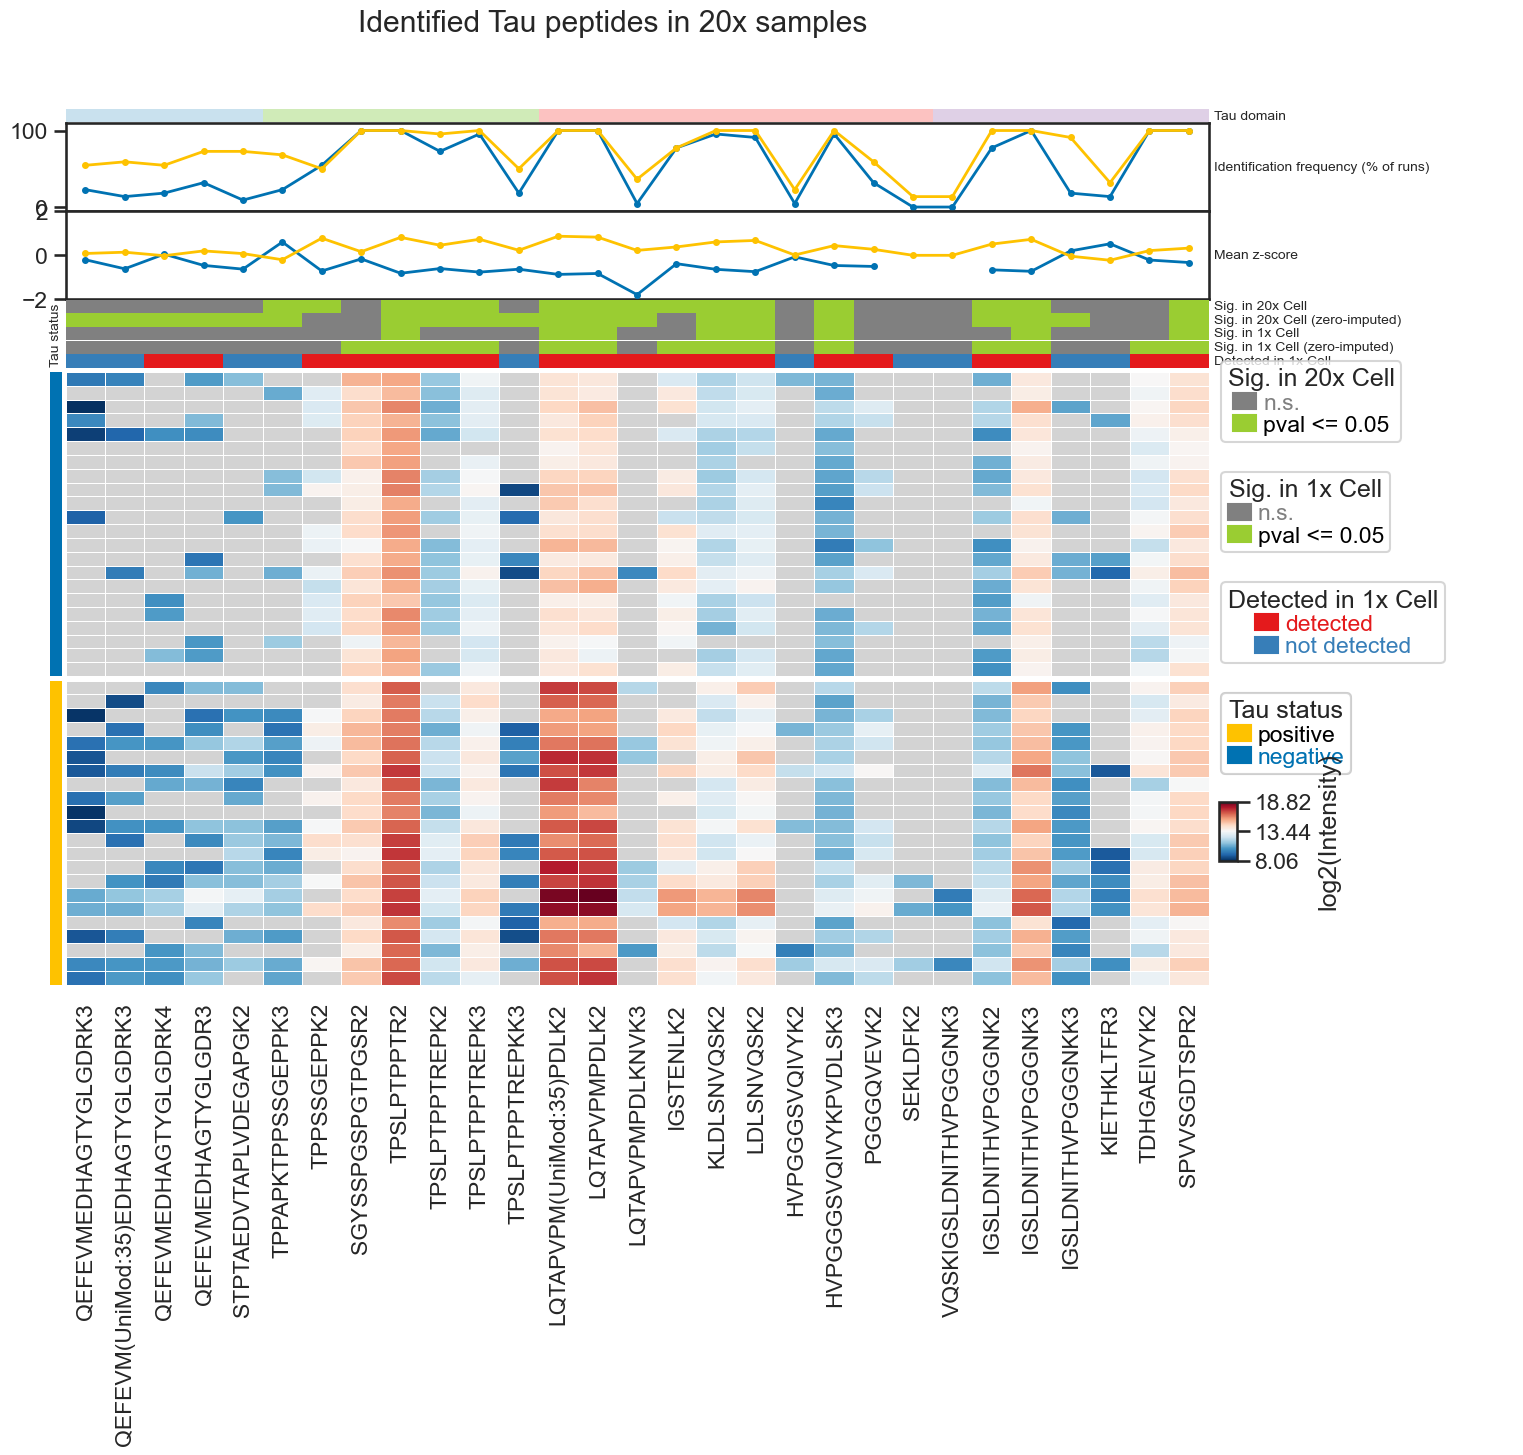

In [618]:
col_ha = pch.HeatmapAnnotation(Domain=pch.anno_simple(annot_col['domain'], legend=False, label='Tau domain', colors={'N-term':'#A6CEE3', 'Proline-rich':'#B2DF8A', 'MTBR':'#FB9A99','C-term':'#CAB2D6'}, alpha=0.6),
                               Line=pch.anno_lineplot(annot_col[['profile_neg', 'profile_pos']], colors=['#0072B2', '#FEC200'], linewidth=2, marker='o', legend=False, height=20, label='Identification frequency (% of runs)', ylim=(-5, 110), markersize=4),
                               Scatter=pch.anno_lineplot(annot_col[['intensity_neg', 'intensity_pos']], colors=['#0072B2', '#FEC200'], legend=False, linewidth=2, marker='o', ylim=(-2, 2), height=20, label='Mean z-score', markersize=4),
                               Significant_mini_bulk_non=pch.anno_simple(annot_col['Significant in mini-bulk (non-imputed)'], legend=True, label='Sig. in 20x Cell', colors={'n.s.':'grey','pval <= 0.05':'yellowgreen'}),
                               Significant_mini_bulk_zero=pch.anno_simple(annot_col['Significant in mini-bulk (zero-imputed)'], legend=False, label='Sig. in 20x Cell (zero-imputed)', colors={'n.s.':'grey','pval <= 0.05':'yellowgreen'}),
                               Significant_single_non=pch.anno_simple(annot_col['Significant in single (non-imputed)'], legend=True, label='Sig. in 1x Cell', colors={'n.s.':'grey','pval <= 0.05':'yellowgreen'}),
                               Significant_single_zero=pch.anno_simple(annot_col['Significant in single (zero-imputed)'], legend=False, label='Sig. in 1x Cell (zero-imputed)', colors={'n.s.':'grey','pval <= 0.05':'yellowgreen'}),
                               detected_single=pch.anno_simple(annot_col['Detected in single'], legend=True, label='Detected in 1x Cell'),
                               label_kws=dict(fontsize=10),
                               axis=1)

row_ha = pch.HeatmapAnnotation(
    df=annot_row,
    axis=0,
    legend=True,
    colors={'Tau status': {'positive': '#FEC200',
                           'negative': '#0072B2'}},
    label_kws=dict(fontsize=10)
)

data = gene_wide.reset_index(drop=True).fillna(-5)
cmap = plt.cm.RdBu_r.with_extremes(under="lightgrey")

plt.figure(figsize=(15, 10))
cm = pch.ClusterMapPlotter(
    data=data,
    left_annotation=row_ha,
    top_annotation=col_ha,
    col_cluster=False,
    row_cluster=False,
    label='log2(Intensity)',
    vmin=gene_wide.min().min(),
    show_rownames=False,
    show_colnames=True,
    linewidth=0.5,
    linecolor='white',
    cmap=cmap,
    row_split=annot_row['Tau status'],
    row_split_gap=1,
    xticklabels_kws={'labelrotation':+90},
)

plt.suptitle('Identified Tau peptides in 20x samples')